# Unsteady Time Integration

implement Forward Euler and AB2
$$\frac{du}{dt} = -u, \quad u(0)=1 \quad \text{(exact solution: } u=e^{-t}\text{)}$$
use Δt = 0.5 over t ∈ [0, 5]

## import library

In [204]:
import numpy as np
import matplotlib.pyplot as plt

## Time setup

In [205]:
dt = 0.5
t = np.arange(0, 5+dt, dt)

print("Time vector:", t)

Time vector: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


## plot exact solution

Exact solution: [1.         0.60653066 0.36787944 0.22313016 0.13533528 0.082085
 0.04978707 0.03019738 0.01831564 0.011109   0.00673795]


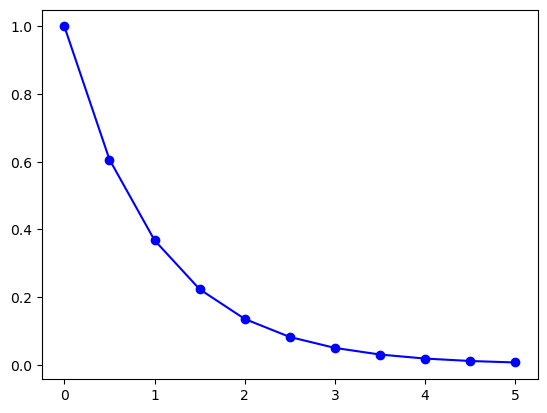

In [206]:
# exact solution

def get_exact_solution(t):
    return np.exp(-t)

u_exact = get_exact_solution(t)
print("Exact solution:", u_exact)
plt.plot(t, u_exact, label='Exact Solution', color='b', marker='o')

## Function of currrent term
Function to compute the $$F(u^n)$$ for the ODE $$\frac{du}{dt} = -u$$

In [207]:
def F(u):
    return -u

## Forward Euler

Forward Euler solution: [1.000000e+00 5.000000e-01 2.500000e-01 1.250000e-01 6.250000e-02
 3.125000e-02 1.562500e-02 7.812500e-03 3.906250e-03 1.953125e-03
 9.765625e-04]


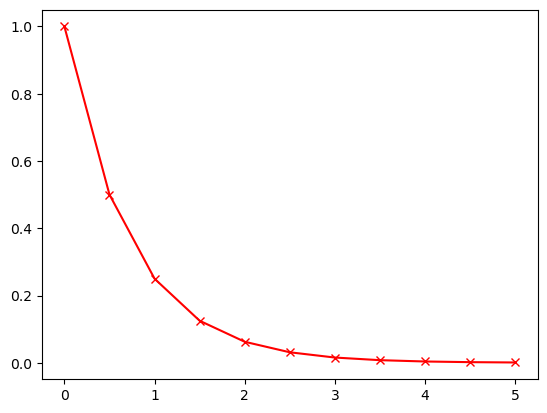

In [208]:
# Forward Euler method

def forward_euler(u0, dt, t):
    u = np.zeros_like(t)
    u[0] = u0
    for n in range(len(t)-1):
        u[n+1] = u[n] + dt * F(u[n])
    return u

u_forward_euler = forward_euler(1.0, dt, t)

print("Forward Euler solution:", u_forward_euler)
plt.plot(t, u_forward_euler, label='Forward Euler', color='r', marker='x')

## Adams-Bashforth 2

Adams-Bashforth 2nd order solution: [1.         0.5        0.375      0.21875    0.1484375  0.09179688
 0.06005859 0.03796387 0.02450562 0.01561737 0.01003075]


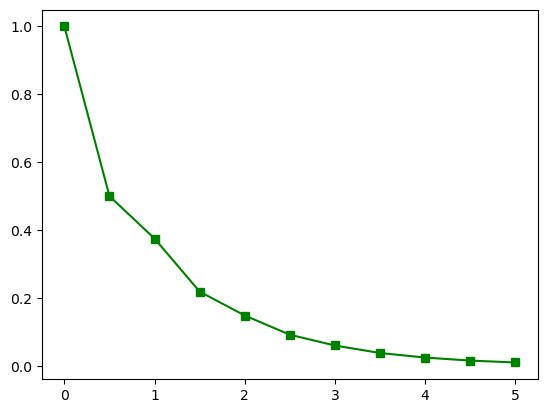

In [209]:
def adams_bashforth_2nd_order(u0, dt, t):    
    u_ab2 = np.zeros_like(t)
    u_ab2[0] = 1.0  # initial condition
    # Adams-Bashforth 2nd order method
    # Use Forward Euler for the first step
    u_ab2[1] = u_ab2[0] + dt * F(u_ab2[0])
    for n in range(1, len(t) - 1):
        u_ab2[n+1] = u_ab2[n] + dt * (1.5 * F(u_ab2[n]) - 0.5 * F(u_ab2[n-1]))

    return u_ab2

u_ab2 = adams_bashforth_2nd_order(1.0, dt, t)
print("Adams-Bashforth 2nd order solution:", u_ab2)
plt.plot(t, u_ab2, label='Adams-Bashforth 2nd Order', color='g', marker='s')

## Runge kutta method

Runge-Kutta 4th order solution: [1.         0.60677083 0.36817084 0.22339533 0.13554977 0.08224765
 0.04990547 0.03028119 0.01837374 0.01114865 0.00676468]


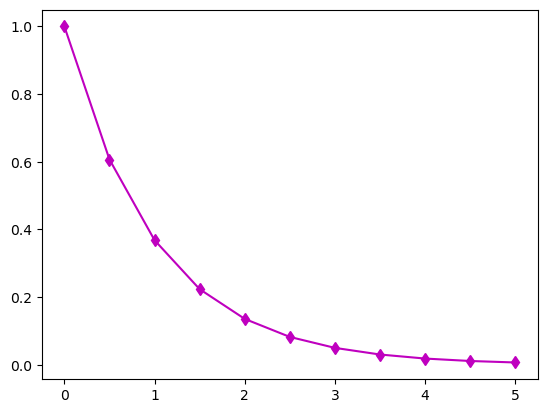

In [210]:
def runge_kutta_4th_order(u0, dt, t):
    u_rk4 = np.zeros_like(t)
    u_rk4[0] = u0
    for n in range(len(t)-1):
        k1 = F(u_rk4[n])
        k2 = F(u_rk4[n] + 0.5 * dt * k1)
        k3 = F(u_rk4[n] + 0.5 * dt * k2)
        k4 = F(u_rk4[n] + dt * k3)
        u_rk4[n+1] = u_rk4[n] + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
    return u_rk4

rk4_solution = runge_kutta_4th_order(1.0, dt, t)
print("Runge-Kutta 4th order solution:", rk4_solution)
plt.plot(t, rk4_solution, label='Runge-Kutta 4th Order', color='m', marker='d')

## Compare the results

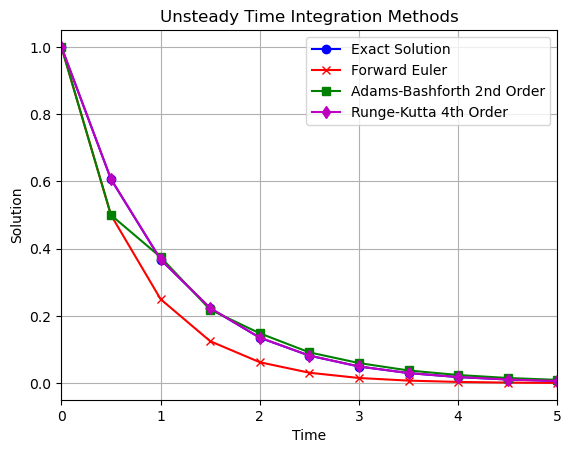

In [211]:
plt.xlabel('Time')
plt.ylabel('Solution')
plt.title('Unsteady Time Integration Methods')
plt.xlim([0, 5])
plt.plot(t, u_exact, label='Exact Solution', color='b', marker='o')
plt.plot(t, u_forward_euler, label='Forward Euler', color='r', marker='x')
plt.plot(t, u_ab2, label='Adams-Bashforth 2nd Order', color='g', marker='s')
plt.plot(t, rk4_solution, label='Runge-Kutta 4th Order', color='m', marker='d')
plt.legend()
plt.grid()

## Error in the solution

Error comparison table:
Time       Forward Euler Error  Adams-Bashforth 2nd Order Error Runge-Kutta 4th Order Error
0.0        0.0                  0.0                  0.0                 
0.5        0.10653065971263342  0.10653065971263342  -0.00024017362069994608
1.0        0.11787944117144233  -0.007120558828557666 -0.0002914030125855116
1.5        0.09813016014842982  0.004380160148429818 -0.00026516978614957165
2.0        0.0728352832366127   -0.013102216763387298 -0.00021448727056699868
2.5        0.0508349986238988   -0.0097118763761012  -0.00016264858488472533
3.0        0.034162068367863944 -0.010271525382136056 -0.00011840506871563933
3.5        0.0223848834223185   -0.007766483765181499 -8.380228268942483e-05
4.0        0.014409388888734179 -0.006189976345640821 -5.810139581489959e-05
4.5        0.009155871538242306 -0.004508374067226444 -3.9653165663776704e-05
5.0        0.005761384499085467 -0.0032927994608754705 -2.672847229504699e-05


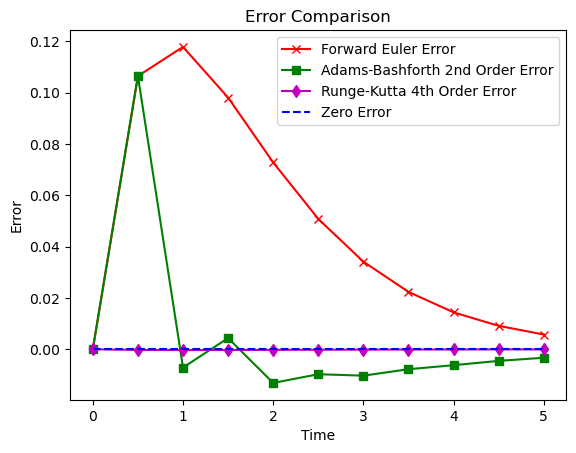

In [212]:
forward_euler_error = u_exact - u_forward_euler
ab2_error = u_exact - u_ab2
rk4_error = u_exact - rk4_solution
print("Error comparison table:")
print("{:<10} {:<20} {:<20} {:<20}".format("Time", "Forward Euler Error", "Adams-Bashforth 2nd Order Error", "Runge-Kutta 4th Order Error"))
for i in range(len(t)):
    print("{:<10} {:<20} {:<20} {:<20}".format(t[i], forward_euler_error[i], ab2_error[i], rk4_error[i]))

plt.figure()
plt.plot(t, forward_euler_error, label='Forward Euler Error', color='r', marker='x')
plt.plot(t, ab2_error, label='Adams-Bashforth 2nd Order Error', color='g', marker='s')
plt.plot(t, rk4_error, label='Runge-Kutta 4th Order Error', color='m', marker='d')
plt.plot(t, np.zeros_like(t), label='Zero Error', color='b', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()

## with many smaller time steps

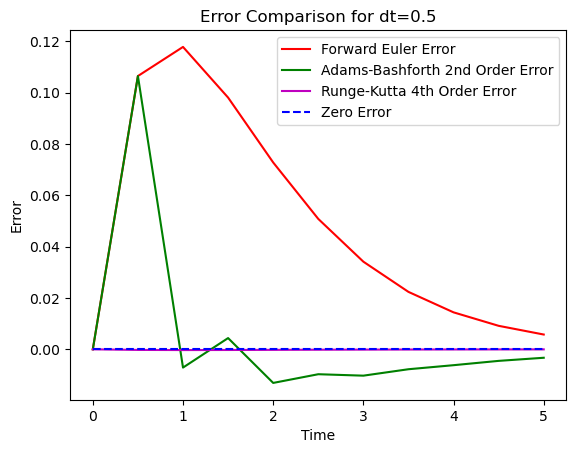

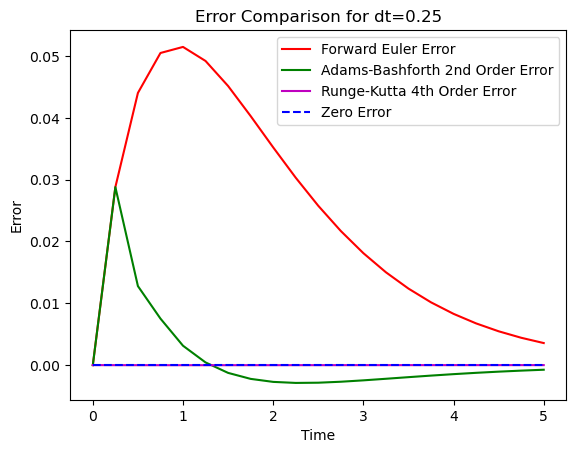

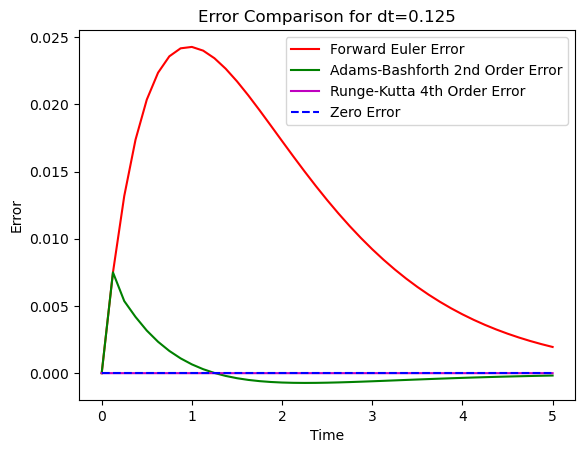

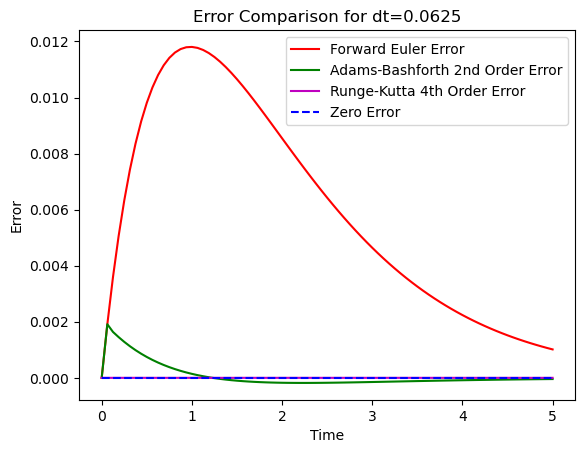

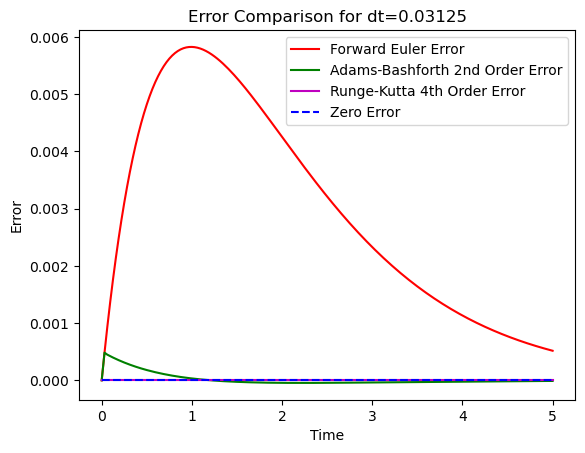

In [213]:
dt_list = [0.5, 0.25, 0.125, 0.0625, 0.03125]

euler_errors = []
ab2_errors = []
rk4_errors = []

for dt in dt_list:
    t = np.arange(0, 5+dt, dt)
    u_exact = get_exact_solution(t)
    u_forward_euler = forward_euler(1.0, dt, t)
    u_ab2 = adams_bashforth_2nd_order(1.0, dt, t)
    u_rk4 = runge_kutta_4th_order(1.0, dt, t)

    forward_euler_error = u_exact - u_forward_euler
    ab2_error = u_exact - u_ab2
    rk4_error = u_exact - u_rk4

    euler_errors.append(np.max(np.abs(forward_euler_error)))
    ab2_errors.append(np.max(np.abs(ab2_error)))
    rk4_errors.append(np.max(np.abs(rk4_error)))

    plt.figure()
    plt.plot(t, forward_euler_error, label='Forward Euler Error', color='r')
    plt.plot(t, ab2_error, label='Adams-Bashforth 2nd Order Error', color='g')
    plt.plot(t, rk4_error, label='Runge-Kutta 4th Order Error', color='m')
    plt.plot(t, np.zeros_like(t), label='Zero Error', color='b', linestyle='--')
    plt.xlabel('Time')
    plt.ylabel('Error')
    plt.title(f'Error Comparison for dt={dt}')
    plt.legend()

## plot loglog error

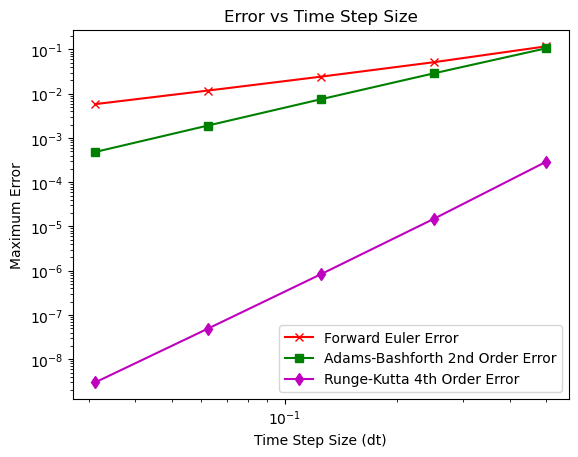

In [214]:
# loglog plot for error vs dt
plt.figure()
plt.loglog(dt_list, euler_errors, label='Forward Euler Error', color='r', marker='x')
plt.loglog(dt_list, ab2_errors, label='Adams-Bashforth 2nd Order Error', color='g', marker='s')
plt.loglog(dt_list, rk4_errors, label='Runge-Kutta 4th Order Error', color='m', marker='d')
plt.xlabel('Time Step Size (dt)')
plt.ylabel('Maximum Error')
plt.title('Error vs Time Step Size')
plt.legend()

## Stability Region Plot

In [215]:
x = np.linspace(-4, 2, 400)
y = np.linspace(-3, 3, 400)

# z = x + iy
z = x + 1j * y[:, np.newaxis]

g_euler = 1 + z
g_rk_4 = 1 + z + (z**2)/2 + (z**3)/6 + (z**4)/24

Text(0, 0.5, 'Im(z)')

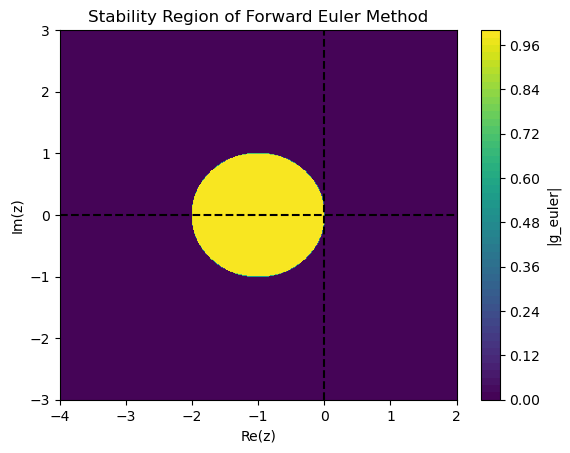

In [216]:
plt.figure()
plt.contourf(x, y, np.abs(g_euler) <= 1, levels=50, cmap='viridis')
plt.colorbar(label='|g_euler|')
# Real axis
plt.plot(x, np.zeros_like(x), color='k', linestyle='--')
# Imaginary axis
plt.plot(np.zeros_like(y), y, color='k', linestyle='--')
plt.title('Stability Region of Forward Euler Method')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')

Text(0, 0.5, 'Im(z)')

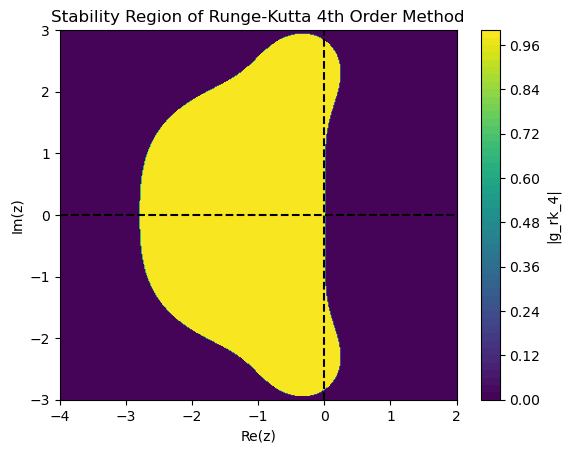

In [217]:
plt.figure()
plt.contourf(x, y, np.abs(g_rk_4) <= 1, levels=50, cmap='viridis')
plt.colorbar(label='|g_rk_4|')
# Real axis
plt.plot(x, np.zeros_like(x), color='k', linestyle='--')
# Imaginary axis
plt.plot(np.zeros_like(y), y, color='k', linestyle='--')
plt.title('Stability Region of Runge-Kutta 4th Order Method')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')